# Customer Segmentation & Churn Prediction Analysis

In this project, I analyze transaction data to identify high-value customer segments and predict churn risk to inform marketing retention strategies.

The dataset used here comes from [https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci?resource=download](this Kaggle page:)

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import math
import missingno as msno
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
data_path = r'./online_retail_II.csv'
df = pd.read_csv(data_path)
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [3]:
pd.set_option('display.max_rows', None)      # show all rows
pd.set_option('display.width', None)         # auto-detect display width
pd.set_option('display.max_colwidth', None)  # show full content in each column

def data_overview(df, head=10):
    print(' DIMENSIONALITY '.center(125, '-'))
    print('Rows:{}'.format(df.shape[0]))
    print('Columns:{}'.format(df.shape[1]))
    print(' DISTRIBUTION OF DATA TYPES '.center(125, '-'))
    print(df.dtypes.value_counts())
    print(' MISSING VALUES '.center(125, '-'))
    print(df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending = False))
    print(' DUPLICATED VALUES '.center(125,'-'))
    print(df.duplicated().sum())
    print(' STATISTICS OF DATA '.center(125,'-'))
    print(df.describe(include="all"))
    print(' DATA INFO '.center(125,'-'))
    print(df.info())
    

# make a copy of the dataframe for manipulation
data = df
data_overview(data)

------------------------------------------------------- DIMENSIONALITY ------------------------------------------------------
Rows:1067371
Columns:8
------------------------------------------------- DISTRIBUTION OF DATA TYPES ------------------------------------------------
object     5
float64    2
int64      1
Name: count, dtype: int64
------------------------------------------------------- MISSING VALUES ------------------------------------------------------
Customer ID    243007
Description      4382
dtype: int64
----------------------------------------------------- DUPLICATED VALUES -----------------------------------------------------
34335
----------------------------------------------------- STATISTICS OF DATA ----------------------------------------------------
        Invoice StockCode                         Description      Quantity  \
count   1067371   1067371                             1062989  1.067371e+06   
unique    53628      5305                                5698

---
# DATA WRANGLING
---

### (1) Removing Missing Data:

<Axes: >

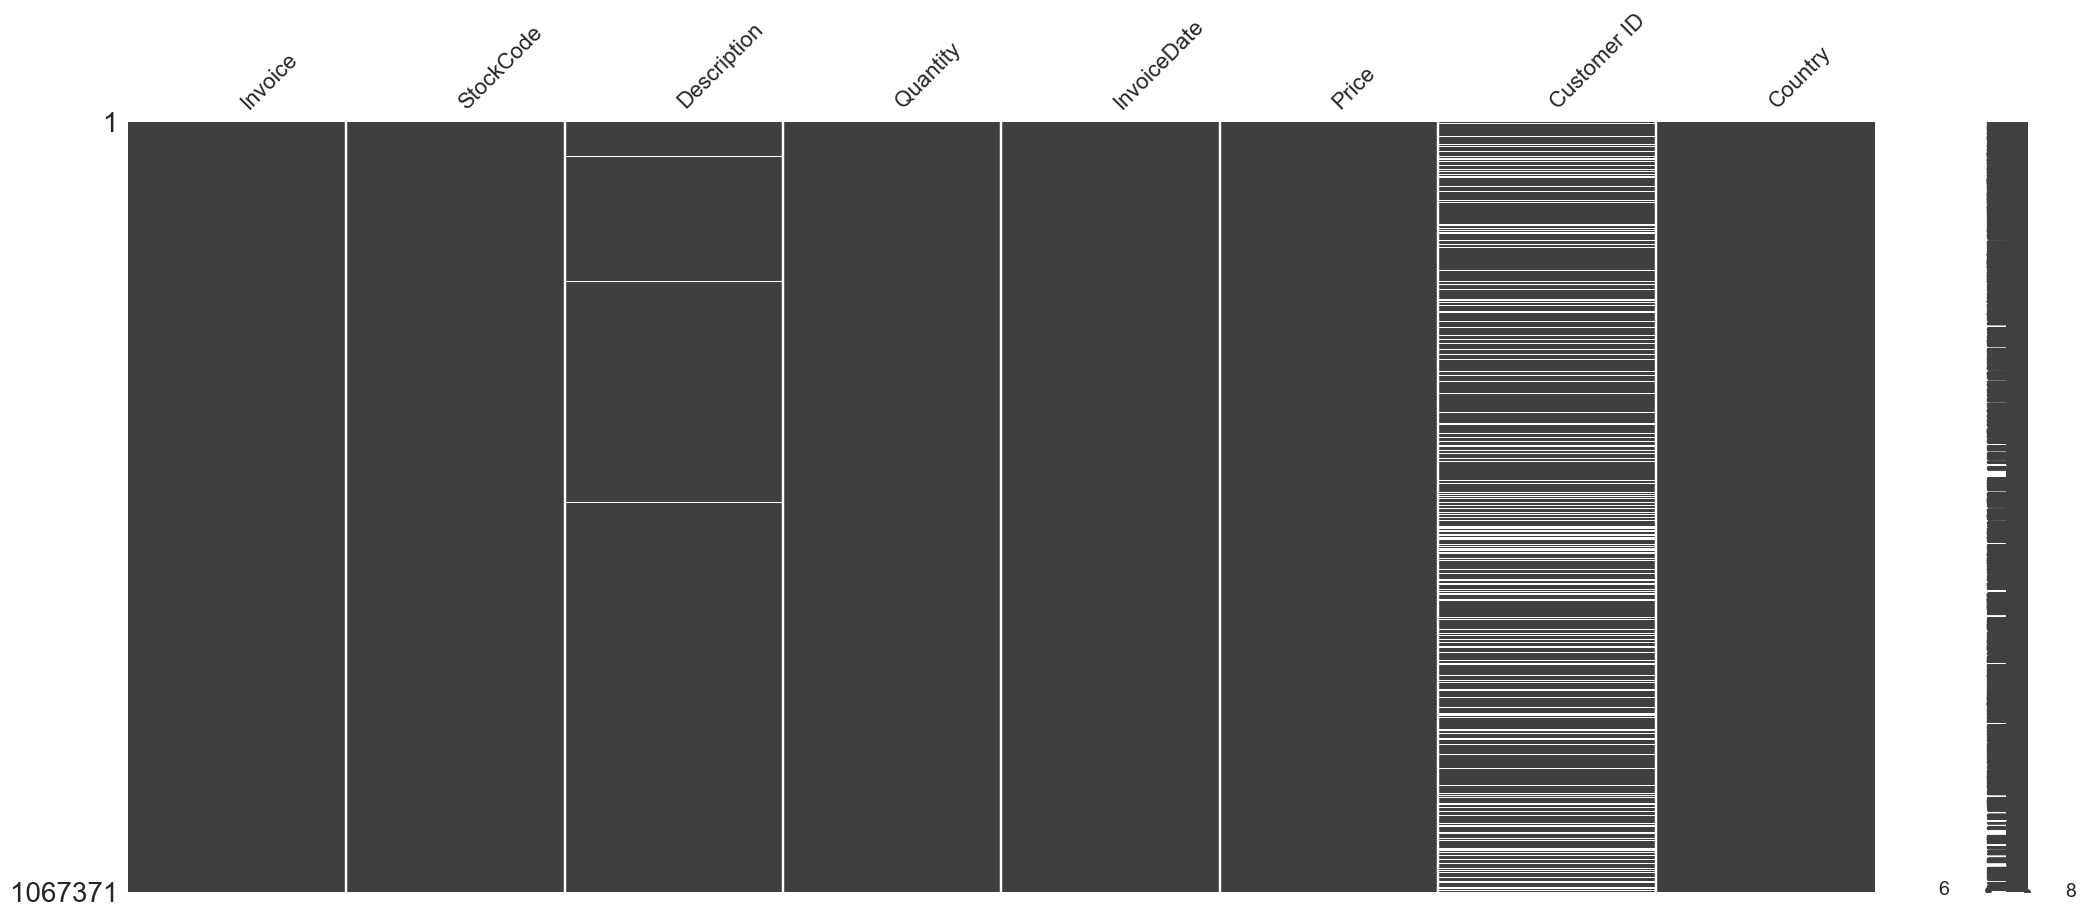

In [4]:
msno.matrix(data)

In [5]:
#  Removing NaN's in Customer ID
print("Shape of data before removing NaN's CustomerID", data.shape)
data.dropna(subset=["Customer ID"], axis=0, inplace=True)
print("Shape of data after removing NaN's CustomerID", data.shape)

Shape of data before removing NaN's CustomerID (1067371, 8)
Shape of data after removing NaN's CustomerID (824364, 8)


In [6]:
print("Missing values in each column after cleaning customerID :\n", data.isnull().sum())

Missing values in each column after cleaning customerID :
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


<Axes: >

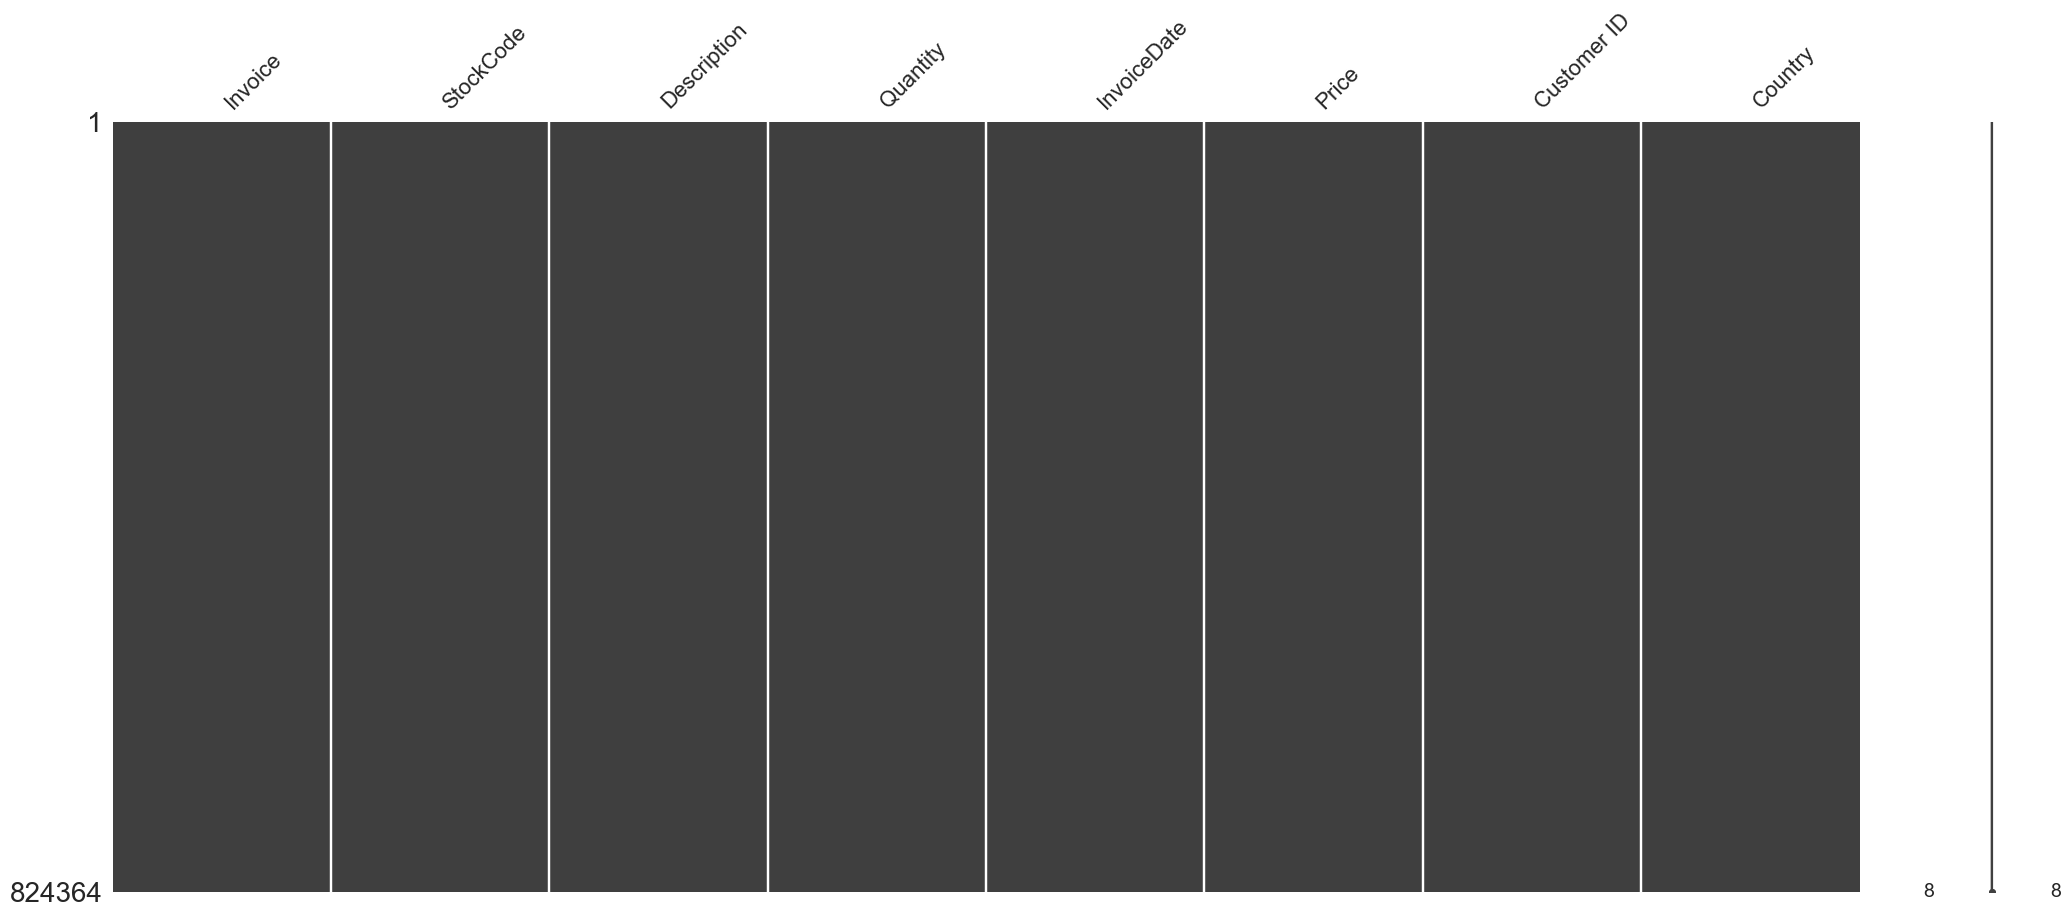

In [7]:
msno.matrix(data)

### (2) Removing Cancelled Products from Invoice:

In [8]:
#using one's compliment operator (~) we can unselect all the Invoice column which doesnt contain "C".
data = data[~data.Invoice.str.contains('C', na=False)]
print("Dataset does not contain info on cancelled products")

Dataset does not contain info on cancelled products


### (3) Removing Duplicates:

In [9]:
# Removing duplicates entries (where values in all columns are identical)
print("Number of duplicates before cleaning:", data.duplicated().sum())
data = data.drop_duplicates(keep="first")
print("Number of duplicates after cleaning:", data.duplicated().sum())

Number of duplicates before cleaning: 26125
Number of duplicates after cleaning: 0


### (4) Checking for Negative Values:

In [10]:
print("Negative value in Quantity is:", (data.Quantity<0).sum())
print("Negative value in Price is:", (data.Price<0).sum())

Negative value in Quantity is: 0
Negative value in Price is: 0


### (5) Cleaning Outliers

In [11]:
#defining funcation to remove outliers w.r.t its thresholds
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.01)
    quartile3 = dataframe[variable].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return up_limit, low_limit

def replace_with_threshold(dataframe, variable):
    up_limit, low_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

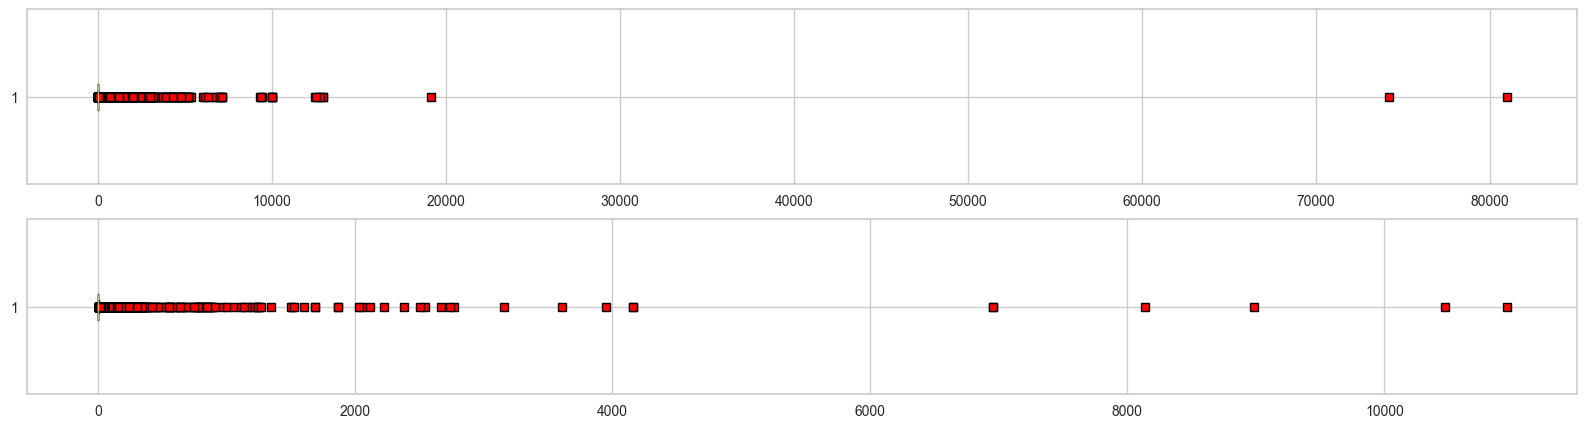

In [12]:
# Observing them BEFORE removing outliers.
f, ax = plt.subplots(2, 1, figsize=(20,5))
col_list = ["Quantity", "Price"]
for i in range(0,2):
    ax[i].boxplot([data[col_list[i]]],
              flierprops=dict(marker="s", markerfacecolor="red"),
              vert=False)
plt.show()

In [13]:
# Applying the functions for removing the outliers.
replace_with_threshold(data, "Quantity")
replace_with_threshold(data, "Price")

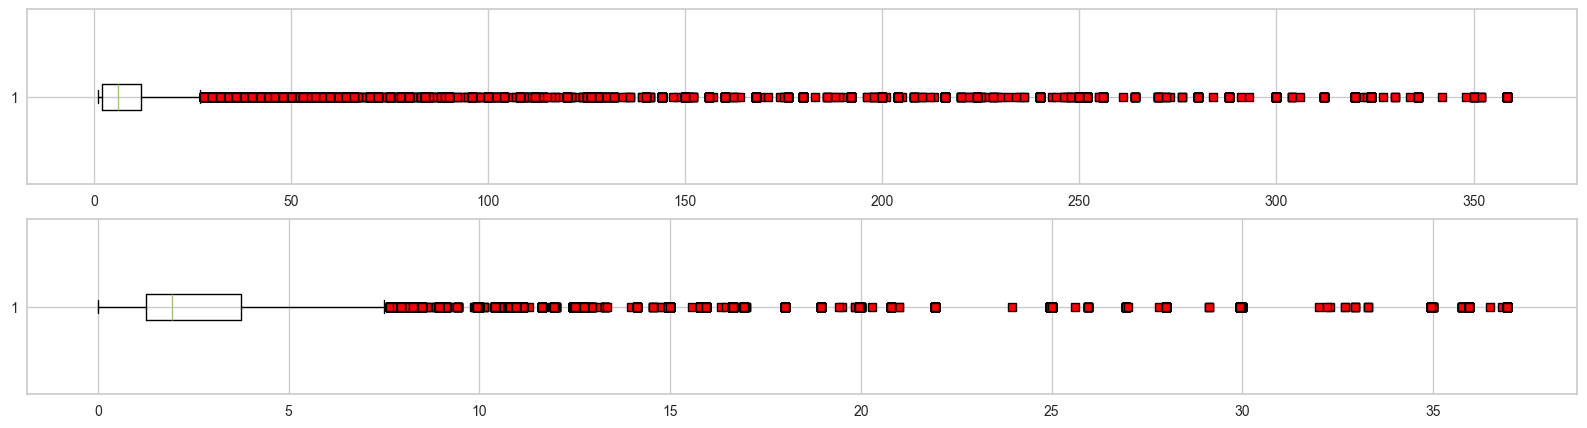

In [14]:
# Observing them AFTER removing outliers.
f, ax = plt.subplots(2, 1, figsize=(20,5))
for i in range(0,2):
    ax[i].boxplot([data[col_list[i]]],
              flierprops=dict(marker="s", markerfacecolor="red"),
              vert=False)
plt.show()

## Data is Clean 

---
# Exploratory Data Analysis & Feature Engineering
---

In [15]:
#First, we define a new feature called "Revenue" which is the quantity of an item multiplied by its unit price:
data["Revenue"] = data["Quantity"] * data["Price"]

In [16]:
#Creating Features for RFM Model
#Changing data type to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [17]:
print("Latest date :", data["InvoiceDate"].max())
print("Earliest date :", data["InvoiceDate"].min())

Latest date : 2011-12-09 12:50:00
Earliest date : 2009-12-01 07:45:00


## RFM Featuring

In [18]:
#Set Latest date 2011-12-10 as last invoice date was 2011-12-09.
Latest_Date = dt.datetime(2011,12,10)

#Creating RFM features with subset of customerID, by collapsing the dataset so that each row = one customer.

RFM = data.groupby('Customer ID').agg({'InvoiceDate': lambda x: (Latest_Date - x.max()).days, 
                                       'Invoice': lambda x: x.nunique(), 
                                       'Revenue': lambda x: x.sum()})
                                
RFM['InvoiceDate'] = RFM['InvoiceDate'].astype(int)

#Renaming column names to Recency, Frequency and Monetary
RFM.rename(columns={'InvoiceDate': 'Recency', 
                         'Invoice': 'Frequency', 
                         'Revenue': 'Monetary'}, inplace=True)


In [19]:
RFM.head().style.format({
    "Recency": "{:.0f}",
    "Frequency": "{:.0f}",
    "Monetary": "{:.2f}"
})

,Recency,Frequency,Monetary
Customer ID,,,
12346.000000,325,12,745.70
12347.000000,2,8,4921.53
12348.000000,75,5,1991.86
12349.000000,18,4,3786.50
12350.000000,310,1,331.34


Now, for each customer we have how recent, how often they've purchased goods, as well as how much in total they've spent.

## Add a New Feature: Customer Lifespan

In [20]:
# First, we filter out any one-timers, and consider only returning customers:
RFM = RFM[(RFM['Frequency'] > 1)]
RFM.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,325,12,745.70
12347.0,2,8,4921.53
12348.0,75,5,1991.86
12349.0,18,4,3786.50
12352.0,36,10,2098.94


In [21]:
shopping_cycle = data.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (x.max() - x.min()).days
}).rename(columns={'InvoiceDate': 'Shopping Cycle'})

RFM = RFM.join(shopping_cycle)
RFM.head()

,Recency,Frequency,Monetary,Shopping Cycle
Customer ID,,,,
12346.0,325,12,745.70,400
12347.0,2,8,4921.53,402
12348.0,75,5,1991.86,362
12349.0,18,4,3786.50,570
12352.0,36,10,2098.94,356


In [22]:
RFM['Interpurchase Time'] = RFM['Shopping Cycle'] // RFM['Frequency']
RFMT = RFM[['Recency', 'Frequency', 'Monetary', 'Interpurchase Time']]
RFMT.head()

,Recency,Frequency,Monetary,Interpurchase Time
Customer ID,,,,
12346.0,325,12,745.70,33
12347.0,2,8,4921.53,50
12348.0,75,5,1991.86,72
12349.0,18,4,3786.50,142
12352.0,36,10,2098.94,35


In [23]:
#scaling data 
scaler = StandardScaler()
rfmt_scaled = scaler.fit_transform(RFMT)
rfmt_scaled = pd.DataFrame(rfmt_scaled)
rfmt_scaled.head()

,0,1,2,3
0,1.084371,0.249370,-0.191464,-0.674702
1,-0.831478,-0.020777,0.077446,-0.355286
2,-0.398484,-0.223387,-0.111216,0.058076
3,-0.736575,-0.290924,0.004353,1.373320
4,-0.629810,0.114297,-0.104320,-0.637124


---
# Modeling with K-Means Algorithm
---

In [24]:
# # First, we find the initial K using the conventional Elbow method:
# plt.figure(figsize=(10,5))
# ax = plt.axes()

# scaler = StandardScaler()

# RFMT_scaled = pd.DataFrame(
#     scaler.fit_transform(RFMT),
#     columns=RFMT.columns
# )

# model = KMeans(n_clusters=2, n_init=10, random_state=42)

# Elbow_M = KElbowVisualizer(model, k=(1,10), metric='distortion')

# Elbow_M.fit(RFMT_scaled)
# Elbow_M.show()

In [25]:
# import sklearn
# import yellowbrick

# print(sklearn.__version__)
# print(yellowbrick.__version__)

In [26]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(rmft_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

NameError: name 'rmft_scaled' is not defined

In [ ]:

# kmeans = KMeans(n_clusters=4, max_iter=50, n_init=10, random_state=42)
# kmeans.fit(RFMT_scaled)

In [ ]:
# RFMT['Clusters'] = kmeans.labels_ # assign cluster to each customer
# RFMT.head(10)

In [ ]:
# RFMT.groupby('Clusters').mean()

In [ ]:
# import matplotlib.pyplot as plt

# plt.scatter(RFMT_scaled[:,0], RFMT_scaled[:,2], c=kmeans.labels_)
# plt.xlabel("Recency (scaled)")
# plt.ylabel("Monetary (scaled)")
# plt.show()